# Implementation of a Deep Asset Liability Management Environment

In [19]:
import os
import sys
import numpy as np
from stable_baselines3 import A2C
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))
from environment.config import markov_config
from environment.bond import Bond
from environment.env import DeepALMEnv
from models.utils import print_bond_universe, plot_learning_curve, plot_final_wealth
from models.source.a2c import evaluate_a2c_agent, evaluate_a2c_alm
from models.DirichletPolicy import DirichletActorCriticPolicy
from typing import Callable

In [20]:
TRAINING = True
DIRICHLET = False

# Create logging directory
if DIRICHLET:
    log_dir = "tmp_log/A2C/Dirichlet/"
    os.makedirs(log_dir, exist_ok=True)
else:
    log_dir = "tmp_log/A2C/Gaussian/"
    os.makedirs(log_dir, exist_ok=True)

## Gym Wrapper for SB3 compatibility

In [21]:
# Create and display bond universe
bonds = [Bond(**cfg) for cfg in markov_config["bond_configs"]]
K = len(bonds)
print_bond_universe(bonds)

# Initialize Training Environment
env = DummyVecEnv([lambda: Monitor(
    DeepALMEnv(markov_config=markov_config, seed=None, use_dirichlet=DIRICHLET), 
    filename=os.path.join(log_dir, "monitor.csv"), 
    info_keywords=('nav',)
)])


-----------------------------------------------
| Bond Type            | Maturity (Months)    |
-----------------------------------------------
| 1M_Bill              | 1                    |
| 3M_ZeroCoupon        | 3                    |
| 6M_ZeroCoupon        | 6                    |
| 12M_6Months          | 12                   |
| 24M_6Months          | 24                   |
-----------------------------------------------


In [ ]:
model = A2C(
    policy=DirichletActorCriticPolicy,
    env=env,

    learning_rate=0.0001,
    
    n_steps=512,

    gamma=1.0,         # No discounting: only care about terminal utility
    gae_lambda=0.95,

    use_sde=False,
    sde_sample_freq=4,
    ent_coef=0.01,


    policy_kwargs=dict(
        net_arch=dict(pi=[256, 256], vf=[256, 256]),
        log_std_init=-2, 
    ),

    verbose=1,
    device="auto"
)

Using cpu device


In [ ]:
if TRAINING:
    print("Starting A2C training...")
    model.learn(total_timesteps=1_000_000, log_interval=10)
    print("Training completed.")
    model.save("saved_models/a2c_alm.zip")
else:
    print("Loading pre-trained model...")
    model = A2C.load("saved_models/a2c_alm.zip")
    
env.training = False
env.norm_reward = False

Starting A2C training...


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 10.2     |
|    ep_rew_mean        | -1.03    |
| time/                 |          |
|    fps                | 430      |
|    iterations         | 10       |
|    time_elapsed       | 11       |
|    total_timesteps    | 5120     |
| train/                |          |
|    entropy_loss       | 5.59     |
|    explained_variance | -5.85    |
|    learning_rate      | 0.001    |
|    n_updates          | 9        |
|    policy_loss        | 3.92     |
|    value_loss         | 0.779    |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 11.1     |
|    ep_rew_mean        | -1.03    |
| time/                 |          |
|    fps                | 455      |
|    iterations         | 20       |
|    time_elapsed       | 22       |
|    total_timesteps    | 10240    |
| train/                |          |
|

KeyboardInterrupt: 

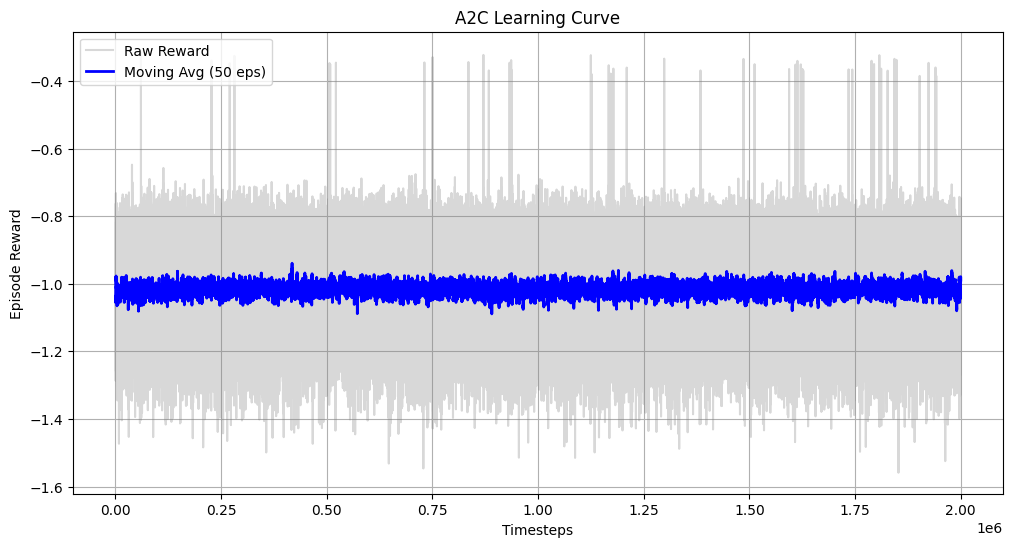

In [ ]:
if TRAINING:
    plot_learning_curve(log_dir, "A2C Learning Curve")

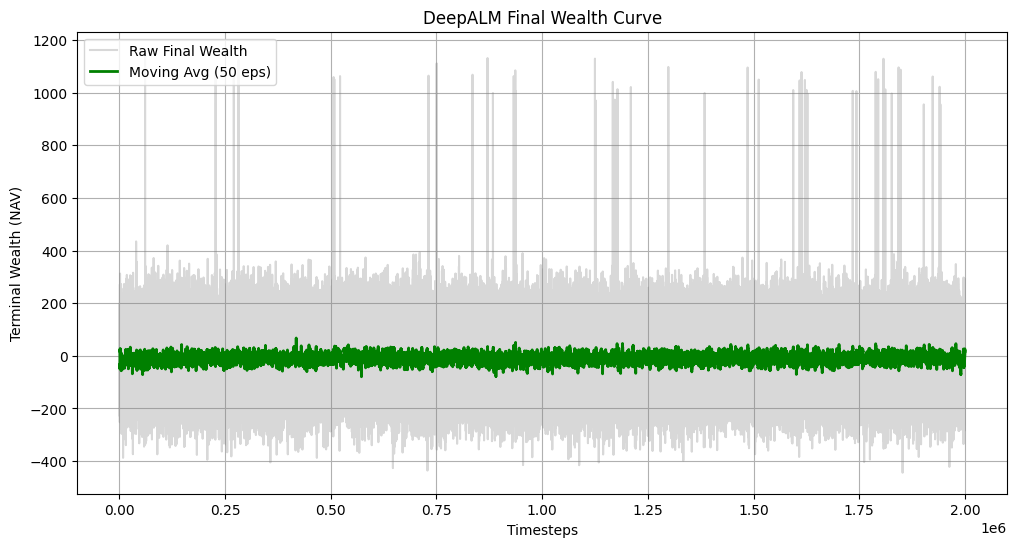

In [ ]:
if TRAINING:
    plot_final_wealth(log_dir)

In [ ]:
# Single-episode evaluation
print("\nRunning Single Episode Deep Dive")
evaluate_a2c_agent(model, markov_config, K, seed=0, verbose=True);


Running Single Episode Deep Dive
Month 1:
1M Bond Lots: None
3M Bond Lots: None
6M Bond Lots: None
12M Bond Lots: None
24M Bond Lots: None
  Current Market Yields
    1M: 1.96%
    3M: 2.54%
    6M: 2.90%
    12M: 3.13%
    24M: 3.29%
  Cash Before Action: 2000.00
  Inflows: 0.00  |  Liability Due: 59.29  |  Next Liability: 59.29
  Cash After Action: 683.49
  LCR: 15.7686  |  Utility: -0.47
  ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  | Bond Type       |        1M        2M        3M        4M        5M        6M        7M        8M        9M       10M       11M       12M       13M       14M       15M       16M       17M       18M       19M       20M       21M       22M       23M       24M |      Total |
  -----------------------------------------------

In [ ]:
# Robust out-of-sample statistical evaluation
model = A2C.load("saved_models/a2c_alm.zip")
print("\nRunning Out-Of-Sample Evaluation")
eval_metrics, eval_raw_results = evaluate_a2c_alm(
    model=model,                       
    markov_config=markov_config,       
    eval_episodes=2000,                
    seed_offset=10_000_000,               
    verbose_first_episode=True         
)


Running Out-Of-Sample Evaluation

--- Starting A2C Evaluation ---
Ep 0 | Month  1 | NAV:   703.21 | LCR: 17.81 | Step Reward: 0.00
Ep 0 | Month  2 | NAV:   709.79 | LCR:  7.17 | Step Reward: 0.00
Ep 0 | Month  3 | NAV:   695.94 | LCR: 10.10 | Step Reward: 0.00
Ep 0 | Month  4 | NAV:   697.08 | LCR:  7.10 | Step Reward: 0.00
Ep 0 | Month  5 | NAV:   719.70 | LCR:  2.49 | Step Reward: 0.00
Ep 0 | Month  6 | NAV:   708.71 | LCR:  6.55 | Step Reward: 0.00
Ep 0 | Month  7 | NAV:   716.70 | LCR:  5.12 | Step Reward: 0.00
Ep 0 | Month  8 | NAV:   712.00 | LCR:  3.45 | Step Reward: 0.00
Ep 0 | Month  9 | NAV:   727.04 | LCR:  2.14 | Step Reward: 0.00
Ep 0 | Month 10 | NAV:   729.68 | LCR:  1.47 | Step Reward: 0.00
Ep 0 | Month 11 | NAV:   225.29 | LCR:  0.80 | Step Reward: 0.00
Ep 0 | Month 12 | NAV:   -29.81 | LCR:  0.00 | Step Reward: -1.03

=== A2C Evaluation Results ===
Mean NAV:       -9.37 ± 115.07
Median NAV:     -11.54
Min / Max NAV:  -446.62 / 1027.18
VaR  (5%):      -194.55
CVaR (5%

In [ ]:
model = A2C.load("saved_models/a2c_alm.zip")
print("\nRunning Out-Of-Sample Evaluation")
eval_metrics, eval_raw_results = evaluate_a2c_alm(
    model=model,                       
    markov_config=markov_config,       
    eval_episodes=100_000,                
    seed_offset=10_000_000,               
    verbose_first_episode=True         
)


Running Out-Of-Sample Evaluation

--- Starting A2C Evaluation ---
Ep 0 | Month  1 | NAV:   703.21 | LCR: 17.81 | Step Reward: 0.00
Ep 0 | Month  2 | NAV:   709.79 | LCR:  7.17 | Step Reward: 0.00
Ep 0 | Month  3 | NAV:   695.94 | LCR: 10.10 | Step Reward: 0.00
Ep 0 | Month  4 | NAV:   697.08 | LCR:  7.10 | Step Reward: 0.00
Ep 0 | Month  5 | NAV:   719.70 | LCR:  2.49 | Step Reward: 0.00
Ep 0 | Month  6 | NAV:   708.71 | LCR:  6.55 | Step Reward: 0.00
Ep 0 | Month  7 | NAV:   716.70 | LCR:  5.12 | Step Reward: 0.00
Ep 0 | Month  8 | NAV:   712.00 | LCR:  3.45 | Step Reward: 0.00
Ep 0 | Month  9 | NAV:   727.04 | LCR:  2.14 | Step Reward: 0.00
Ep 0 | Month 10 | NAV:   729.68 | LCR:  1.47 | Step Reward: 0.00
Ep 0 | Month 11 | NAV:   225.29 | LCR:  0.80 | Step Reward: 0.00
Ep 0 | Month 12 | NAV:   -29.81 | LCR:  0.00 | Step Reward: -1.03

=== A2C Evaluation Results ===
Mean NAV:       -8.19 ± 114.93
Median NAV:     -10.62
Min / Max NAV:  -446.62 / 1172.79
VaR  (5%):      -191.59
CVaR (5%